In [1]:
# ============================================================
# [Cell 0] 환경 설정 — Colab / 로컬 자동 감지
# ============================================================
import sys, os

try:
    is_colab = 'google.colab' in str(get_ipython())
except NameError:
    is_colab = False

if is_colab:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = '/content/pill_detection_project'
    if not os.path.exists(REPO_DIR):
        os.system('git clone https://github.com/wina0901/pill_detection_project.git ' + REPO_DIR)

    sys.path.insert(0, REPO_DIR)
    BASE_DIR = '/content/drive/MyDrive/data/초급_프로젝트/dataset'

else:
    sys.path.insert(0, os.path.abspath('..'))
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../data'))

print(f"✅ 환경: {'Colab' if is_colab else '로컬'}")
print(f"✅ PROJECT: {sys.path[0]}")
print(f"✅ DATA:    {BASE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 환경: Colab
✅ PROJECT: /content/pill_detection_project
✅ DATA:    /content/drive/MyDrive/data/초급_프로젝트/dataset


In [2]:
# # 한글 폰트 설치
# !apt-get install -y fonts-nanum > /dev/null
# import matplotlib; matplotlib.font_manager._load_fontmanager(try_read_cache=False)

In [3]:
############################################################
# 0. 라이브러리 임포트
############################################################
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import cv2
import glob
import platform
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

# ✅ eda_tools.py의 HealthEatVisualizer 임포트 (폰트 설정 통합)
# Cell 0에서 sys.path에 REPO_DIR이 추가되어 있어야 함
try:
    # 수정 → src에 __init__.py가 없으면 직접 경로 지정
    from src.preprocessing import *   # 이미 동작
    # eda_tools는 별도로:
    import sys
    sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
    from eda_tools import HealthEatVisualizer
    viz = HealthEatVisualizer()
    fp  = viz.fp
    print("✅ HealthEatVisualizer 로드 완료 (폰트 자동 설정)")
except Exception as e:
    print(f"⚠️  eda_tools 로드 실패, 직접 폰트 설정: {e}")
    if platform.system() == 'Darwin':
        plt.rc('font', family='AppleGothic')
        plt.rcParams['axes.unicode_minus'] = False
        fp = fm.FontProperties(family='AppleGothic')
    else:
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        fp = fm.FontProperties(fname=font_path) if os.path.exists(font_path) else fm.FontProperties()
        if os.path.exists(font_path):
            plt.rc('font', family=fp.get_name())


⚠️  eda_tools 로드 실패, 직접 폰트 설정: No module named 'eda_tools'


In [4]:
############################################################
# GPU/MPS 장치 확인 (EDA 참고용)
############################################################
import torch

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps"), "Apple Silicon MPS"
    elif torch.cuda.is_available():
        return torch.device("cuda"), f"NVIDIA GPU ({torch.cuda.get_device_name(0)})"
    else:
        return torch.device("cpu"), "CPU"

DEVICE, device_name = get_device()
print(f"✅ DEVICE: {DEVICE}  [{device_name}]")


✅ DEVICE: cuda  [NVIDIA GPU (NVIDIA L4)]


In [5]:
############################################################
# 1. 원본 JSON 경로 확인 (Cell 0의 BASE_DIR 사용)
############################################################
import os

TARGET_FILE = 'merged_annotations_train_final.json'
DATA_PATH   = os.path.join(BASE_DIR, TARGET_FILE)

print(f"📍 BASE_DIR  : {BASE_DIR}")
print(f"📍 DATA_PATH : {DATA_PATH}")

if os.path.exists(DATA_PATH):
    print("✅ 타겟 파일 확인 완료!")
else:
    print("🚨 [경고] 파일을 찾을 수 없습니다. BASE_DIR 경로를 확인해주세요.")
    raise FileNotFoundError(f"파일 없음: {DATA_PATH}")


📍 BASE_DIR  : /content/drive/MyDrive/data/초급_프로젝트/dataset
📍 DATA_PATH : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json
✅ 타겟 파일 확인 완료!


In [6]:
############################################################
# 2. JSON 어노테이션 로드 및 데이터 구조 해체
############################################################
import json
import os
import pandas as pd

# 💡 [엔지니어링 포인트] 상단에서 OS를 자동 감지하여 세팅한 BASE_DIR을 100% 신뢰하고 사용합니다.
# 하드코딩된 Colab 경로나 불확실한 found_path에 의존하지 않습니다.
json_path = os.path.join(BASE_DIR, 'merged_annotations_train_final.json')

print(f"🚀 [데이터 해체] '{os.path.basename(json_path)}' 분석을 시작합니다...\n")

# 1) 파일 존재 여부 확인 및 로드
if not os.path.exists(json_path):
    print(f"🚨 [에러] '{json_path}' 경로에 파일이 없습니다. 경로 설정을 다시 확인해주세요!")
else:
    with open(json_path, 'r', encoding='utf-8') as f:
        coco_data = json.load(f)
    print("✅ [성공] JSON 파일 로드 완료!\n")
    
    # 2) Pandas DataFrame 변환 (데이터 조작의 효율성 확보)
    images_df = pd.DataFrame(coco_data['images'])
    categories_df = pd.DataFrame(coco_data['categories'])
    annotations_df = pd.DataFrame(coco_data['annotations'])

    print("📊 [데이터 구조] 주요 DataFrame의 기본 정보:")

🚀 [데이터 해체] 'merged_annotations_train_final.json' 분석을 시작합니다...

✅ [성공] JSON 파일 로드 완료!

📊 [데이터 구조] 주요 DataFrame의 기본 정보:


In [7]:
############################################################
# 3. 탐색적 데이터 분석 (EDA) - 데이터 품질 진단
############################################################
import os
import json
import pandas as pd

# BASE_DIR 안전하게 확인 (Cell 0 미실행 대비)
if 'BASE_DIR' not in dir() or not os.path.exists(BASE_DIR):
    # 노트북 위치 기준 상대경로 시도
    _candidates = [
        os.path.abspath(os.path.join(os.getcwd(), '../data')),
        '/content/drive/MyDrive/data/초급_프로젝트/dataset',
    ]
    for _p in _candidates:
        if os.path.exists(os.path.join(_p, 'merged_annotations_train_final.json')):
            BASE_DIR = _p
            break

target_file = 'merged_annotations_train_final.json'
found_path  = os.path.join(BASE_DIR, target_file)

print(f"BASE_DIR : {BASE_DIR}")
print(f"파일 존재 : {os.path.exists(found_path)}")

if os.path.exists(found_path):
    with open(found_path, 'r', encoding='utf-8') as f:
        coco_data = json.load(f)

    images_df      = pd.DataFrame(coco_data['images'])
    categories_df  = pd.DataFrame(coco_data['categories'])
    annotations_df = pd.DataFrame(coco_data['annotations'])
    print(f"파일 경로 확인 완료! : {found_path}")
else:
    raise FileNotFoundError(f"JSON 파일을 찾을 수 없습니다: {found_path}")

# --- [Step 1] 최상위 구조 파악 ---
print(f"{'='*20} [1단계] 데이터 로드 완료 {'='*20}")
print(f"Structure: {list(coco_data.keys())}")
print("-" * 60)

# --- [Step 2] 데이터 규모 요약 ---
print(f"{'='*20} [2단계] 데이터 규모 요약 {'='*20}")
print(f"• 총 이미지 수: {len(images_df):,} 장")
print(f"• 알약 클래스 수: {len(categories_df):,} 개")
print(f"• Bounding Box 수: {len(annotations_df):,} 개")
print("-" * 60)

# --- [Step 3] 해상도 분포 ---
print(f"{'='*20} [3단계] 이미지 해상도 분포 {'='*20}")
res_counts = images_df.groupby(['width', 'height']).size().reset_index(name='count')
print(res_counts.to_string(index=False))
print("-" * 60)

# --- [Step 4] 결측치 검사 ---
print(f"{'='*20} [4단계] 결측치(Null) 검사 {'='*20}")
null_report = annotations_df.isnull().sum()
print(null_report[null_report > 0] if null_report.sum() > 0 else "결측치 없음: 데이터 상태가 매우 양호합니다.")
print("-" * 60)

# --- [Step 5] 클래스 불균형 분석 ---
cat_dict = dict(zip(categories_df['id'], categories_df['name']))
annotations_df['class_name'] = annotations_df['category_id'].map(cat_dict)

print(f"{'='*20} [5단계] 클래스 불균형 검증 {'='*20}")
class_counts = annotations_df['class_name'].value_counts()
print(f"[High Frequency] Top 5 (과적합 주의):")
print(class_counts.head(5))
print(f"\n[Low Frequency] Bottom 5 (데이터 증강 필요):")
print(class_counts.tail(5))
print("-" * 60)

# --- [Step 6] 바운딩 박스 크기(Scale) 분석 ---
# ✅ [수정] 컬럼명을 Cell 6/7과 통일 → ['x', 'y', 'w', 'h']
annotations_df[['x', 'y', 'w', 'h']] = pd.DataFrame(annotations_df['bbox'].tolist(), index=annotations_df.index)
annotations_df['area']         = annotations_df['w'] * annotations_df['h']
annotations_df['aspect_ratio'] = annotations_df['w'] / annotations_df['h']

print(f"{'='*20} [6단계] 객체 크기(Scale) 지표 {'='*20}")
min_area = annotations_df['area'].min()
max_area = annotations_df['area'].max()
print(f"• 최소 객체 면적: {min_area:,.2f} px²")
print(f"• 최대 객체 면적: {max_area:,.2f} px²")
print(f"• 면적 Ratio (Max/Min): {max_area / min_area:,.1f} 배")
print("\n[Comment] 객체 크기 차이가 극심할 경우, Faster R-CNN의 Anchor Box size와")
print("FPN 계층별 할당 전략을 재점검해야 합니다.")
print("=" * 60)

BASE_DIR : /content/drive/MyDrive/data/초급_프로젝트/dataset
파일 존재 : True
파일 경로 확인 완료! : /content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json
==================== [1단계] 데이터 로드 완료 ====================
Structure: ['images', 'annotations', 'categories']
------------------------------------------------------------
==================== [2단계] 데이터 규모 요약 ====================
• 총 이미지 수: 1,489 장
• 알약 클래스 수: 73 개
• Bounding Box 수: 4,526 개
------------------------------------------------------------
==================== [3단계] 이미지 해상도 분포 ====================
 width  height  count
   976    1280   1489
------------------------------------------------------------
==================== [4단계] 결측치(Null) 검사 ====================
결측치 없음: 데이터 상태가 매우 양호합니다.
------------------------------------------------------------
==================== [5단계] 클래스 불균형 검증 ====================
[High Frequency] Top 5 (과적합 주의):
class_name
기넥신에프정(은행엽엑스)(수출용)    514
일양하이트린정 2mg           240
보령부스파정 5mg         

🚨 [경고] 지정된 경로에 한글 폰트가 없습니다. 텍스트가 깨질 수 있습니다.


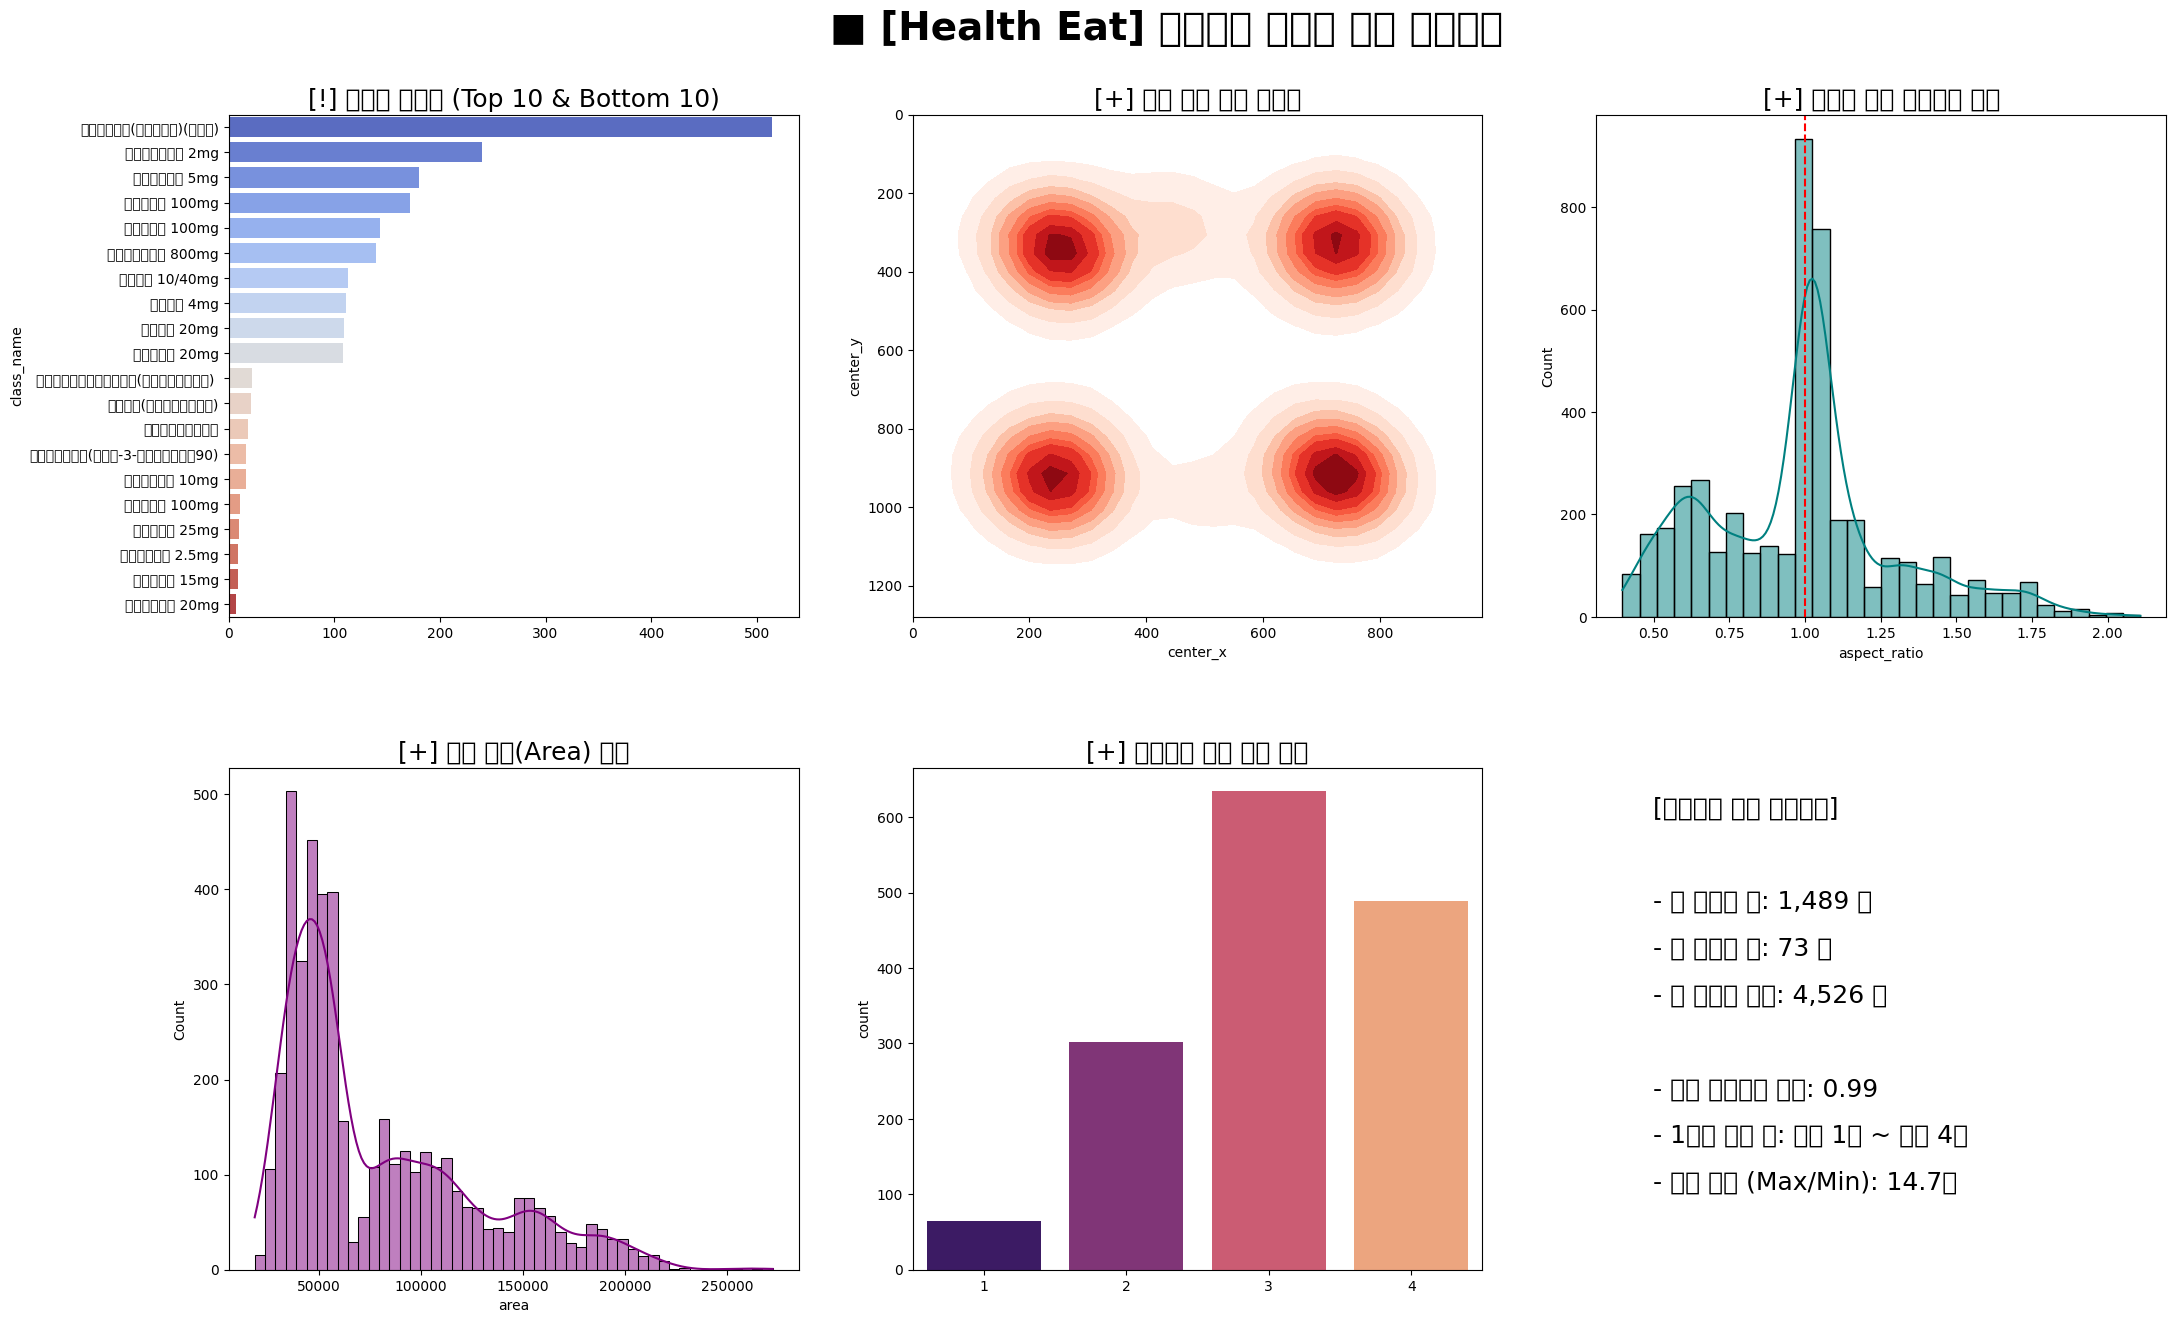

In [8]:
############################################################
# 5. 데이터셋 마스터 분석 대시보드 시각화 (EDA Dashboard)
############################################################
import json
import os
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# ==========================================
# --- [Step 1] OS별 맞춤 한글 폰트 동적 설정 ---
# ==========================================
# # 하드코딩된 경로 대신, 실행 환경(Mac 로컬 vs Colab 리눅스)을 자동 감지합니다.
if platform.system() == 'Darwin':  # macOS 환경 (Apple Silicon 등)
    plt.rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
    fp = fm.FontProperties(family='AppleGothic')
    print("🍎 [시스템] macOS 환경 감지: 'AppleGothic' 폰트 적용 완료")
else:  # Linux (Colab) 환경
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(font_path):
        fp = fm.FontProperties(fname=font_path)
        plt.rc('font', family=fp.get_name())
        print("🐧 [시스템] Linux 환경 감지: 'NanumGothic' 폰트 적용 완료")
    else:
        print("🚨 [경고] 지정된 경로에 한글 폰트가 없습니다. 텍스트가 깨질 수 있습니다.")
        fp = fm.FontProperties() # 기본 폰트 Fallback

# ==========================================
# --- [Step 2] 데이터 로드 및 전처리 ---
# ==========================================
json_path = os.path.join(BASE_DIR, 'merged_annotations_train_final.json')

with open(json_path, 'r', encoding='utf-8') as f:
    coco_data = json.load(f)

images_df = pd.DataFrame(coco_data['images'])
categories_df = pd.DataFrame(coco_data['categories'])
annotations_df = pd.DataFrame(coco_data['annotations'])

cat_dict = dict(zip(categories_df['id'], categories_df['name']))
annotations_df['class_name'] = annotations_df['category_id'].map(cat_dict)
annotations_df[['x', 'y', 'w', 'h']] = pd.DataFrame(annotations_df['bbox'].tolist(), index=annotations_df.index)

# 핵심 파생 변수 계산
annotations_df['area'] = annotations_df['w'] * annotations_df['h']
annotations_df['aspect_ratio'] = annotations_df['w'] / annotations_df['h']
annotations_df['center_x'] = annotations_df['x'] + (annotations_df['w'] / 2)
annotations_df['center_y'] = annotations_df['y'] + (annotations_df['h'] / 2)
pills_per_image = annotations_df.groupby('image_id').size()

# ==========================================
# --- [Step 3] 마스터 통계 대시보드 렌더링 ---
# ==========================================
fig = plt.figure(figsize=(25, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
fig.suptitle('■ [Health Eat] 데이터셋 마스터 분석 대시보드', fontproperties=fp, fontsize=28, fontweight='bold', y=0.95)

# [1] 클래스 불균형 (데이터 편향도)
ax1 = plt.subplot(2, 3, 1)
class_counts = annotations_df['class_name'].value_counts()
extreme_classes = pd.concat([class_counts.head(10), class_counts.tail(10)])
sns.barplot(x=extreme_classes.values, y=extreme_classes.index, palette='coolwarm', ax=ax1)
ax1.set_title('[!] 클래스 불균형 (Top 10 & Bottom 10)', fontproperties=fp, fontsize=18)
for label in ax1.get_yticklabels(): 
    label.set_fontproperties(fp)

# [2] 객체 위치 히트맵 (Spatial Distribution)
ax2 = plt.subplot(2, 3, 2)
sns.kdeplot(x=annotations_df['center_x'], y=annotations_df['center_y'], fill=True, cmap='Reds', ax=ax2)
ax2.set_xlim(0, images_df['width'].max() if not images_df.empty else 976)
ax2.set_ylim(images_df['height'].max() if not images_df.empty else 1280, 0) # y축 뒤집기 (이미지 좌표계)
ax2.set_title('[+] 알약 배치 위치 히트맵', fontproperties=fp, fontsize=18)

# [3] 가로세로 비율 (Aspect Ratio)
ax3 = plt.subplot(2, 3, 3)
sns.histplot(annotations_df['aspect_ratio'], bins=30, kde=True, color='teal', ax=ax3)
ax3.axvline(1.0, color='red', linestyle='--')
ax3.set_title('[+] 바운딩 박스 가로세로 비율', fontproperties=fp, fontsize=18)

# [4] 알약 면적(Area) 분포
ax4 = plt.subplot(2, 3, 4)
sns.histplot(annotations_df['area'], bins=50, kde=True, color='purple', ax=ax4)
ax4.set_title('[+] 알약 면적(Area) 분포', fontproperties=fp, fontsize=18)

# [5] 이미지당 알약 개수 분포
ax5 = plt.subplot(2, 3, 5)
sns.countplot(x=pills_per_image.values, palette='magma', ax=ax5)
ax5.set_title('[+] 이미지당 알약 개수 분포', fontproperties=fp, fontsize=18)

# [6] 요약 텍스트 정보
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = (
    f"[데이터셋 핵심 인사이트]\n\n"
    f"- 총 이미지 수: {len(images_df):,} 장\n"
    f"- 총 클래스 수: {len(categories_df):,} 종\n"
    f"- 총 바운딩 박스: {len(annotations_df):,} 개\n\n"
    f"- 평균 가로세로 비율: {annotations_df['aspect_ratio'].mean():.2f}\n"
    f"- 1장당 알약 수: 최소 {pills_per_image.min()}개 ~ 최대 {pills_per_image.max()}개\n"
    f"- 면적 격차 (Max/Min): {annotations_df['area'].max() / annotations_df['area'].min():.1f}배\n"
)
ax6.text(0.1, 0.5, summary_text, fontproperties=fp, fontsize=18, va='center', linespacing=2.2)

plt.show()

In [9]:
############################################################
# 6. 데이터셋 정밀 통계 분석 (Hyperparameter Tuning Basis)
############################################################
import pandas as pd
import numpy as np
from IPython.display import display # Jupyter/Colab 환경에서 깔끔한 표 출력을 위해 명시적 임포트

# ==========================================
# --- [Step 1] 파생 변수 검증 및 생성 ---
# ==========================================
# 이전 셀을 실행하지 않았을 경우를 대비한 방어적 프로그래밍(Defensive Programming)
# ✅ [수정] Cell 5에서 ['x','y','w','h'] + area/aspect_ratio 생성됨
# 독립 실행(셀 건너뜀) 대비 방어 코드
if 'area' not in annotations_df.columns:
    annotations_df[['x', 'y', 'w', 'h']] = pd.DataFrame(annotations_df['bbox'].tolist(), index=annotations_df.index)
    annotations_df['area']         = annotations_df['w'] * annotations_df['h']
    annotations_df['aspect_ratio'] = annotations_df['w'] / annotations_df['h']
    print("💡 [폴백] 'area' 및 'aspect_ratio' 컬럼 재생성")

# ==========================================
# --- [Step 2] 클래스별 상세 통계 집계 ---
# ==========================================
# 모델의 클래스 불균형(Class Imbalance) 해소 전략을 세우기 위한 핵심 지표입니다.
class_stats = annotations_df.groupby('class_name').agg({
    'id': 'count',
    'area': ['mean', 'min', 'max', 'std'],
    'aspect_ratio': 'mean'
}).reset_index()

# Multi-index 컬럼 평탄화 및 직관적인 이름 부여
class_stats.columns = ['알약 이름', '데이터 개수', '평균 면적', '최소 면적', '최대 면적', '면적 표준편차', '평균 비율(W/H)']
class_stats = class_stats.sort_values(by='데이터 개수', ascending=False)

# ==========================================
# --- [Step 3] 전체 데이터셋 요약 지표 ---
# ==========================================
total_summary = pd.DataFrame({
    '분석 지표': [
        '총 이미지 수', 
        '총 클래스(알약 종류) 수', 
        '총 라벨링(Bounding Box) 수', 
        '이미지 1장당 평균 객체 수', 
        '전체 평균 객체 면적(px²)'
    ],
    '수치': [
        f"{len(images_df):,}",
        f"{len(categories_df):,}",
        f"{len(annotations_df):,}",
        f"{len(annotations_df) / len(images_df):.2f}",
        f"{annotations_df['area'].mean():,.2f}"
    ]
})

# ==========================================
# --- [Step 4] 통계 리포트 출력 ---
# ==========================================
print("\n" + "="*50)
print("[Report 1] 전체 데이터셋 핵심 요약")
print("="*50)
display(total_summary)

print("\n" + "="*50)
print("[Report 2] 🚨 롱테일(Long-tail) 하위 10개 클래스")
print("-> 이 클래스들은 학습 시 Focal Loss 적용 또는 MixUp/Mosaic 증강이 시급합니다.")
print("="*50)
display(class_stats.tail(10))

print("\n" + "="*50)
print("[Report 3] 📐 바운딩 박스 크기 기술 통계 (Anchor Box 기준)")
print("-> 모델의 FPN(Feature Pyramid Network) 스케일 설정 시 참고할 사분위수입니다.")
print("="*50)
# 백분위수(Percentile)를 디테일하게 나누어 극단값(Outlier)의 영향을 파악합니다.
area_desc = annotations_df['area'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
display(pd.DataFrame(area_desc).T.round(2))


[Report 1] 전체 데이터셋 핵심 요약


,분석 지표,수치
0,총 이미지 수,"1,489"
1,총 클래스(알약 종류) 수,73
2,총 라벨링(Bounding Box) 수,"4,526"
3,이미지 1장당 평균 객체 수,3.04
4,전체 평균 객체 면적(px²),"78,884.17"



[Report 2] 🚨 롱테일(Long-tail) 하위 10개 클래스
-> 이 클래스들은 학습 시 Focal Loss 적용 또는 MixUp/Mosaic 증강이 시급합니다.


,알약 이름,데이터 개수,평균 면적,최소 면적,최대 면적,면적 표준편차,평균 비율(W/H)
57,종근당글리아티린연질캡슐(콜린알포세레이트),22,92344.318182,85888,98895,3391.535393,0.762724
2,글리틴정(콜린알포세레이트),21,134365.285714,122360,159185,10709.715940,1.161788
1,글리아타민연질캡슐,18,95449.833333,84272,103342,5118.229453,0.999707
47,오마코연질캡슐(오메가-3-산에틸에스테르90),16,229253.437500,160132,272435,35320.324447,0.752790
38,아빌리파이정 10mg,16,31133.625000,25375,36000,3648.714602,1.238127
56,졸로푸트정 100mg,11,61700.545455,51840,74536,10054.804766,1.700931
62,쿠에타핀정 25mg,10,19097.900000,18492,19734,419.083776,0.990063
13,렉사프로정 15mg,9,43000.111111,39904,46575,2773.742032,0.815041
53,자이프렉사정 2.5mg,9,33624.666667,31122,35910,1805.245690,1.025134
27,브린텔릭스정 20mg,7,34485.000000,32856,37349,1510.789529,1.107914



[Report 3] 📐 바운딩 박스 크기 기술 통계 (Anchor Box 기준)
-> 모델의 FPN(Feature Pyramid Network) 스케일 설정 시 참고할 사분위수입니다.


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
area,4526.0,78884.17,47201.73,18492.0,34596.0,43397.0,57452.0,106294.75,155173.0,180588.0,272435.0


[!] 전체 파일 경로 인덱싱 중...
[OK] 인덱싱 완료! 총 5,907개의 이미지 파일이 매핑되었습니다.
[+] [분석] 조명 및 대비 고속 스캔 중... (N=500)
[+] [분석] Top 클래스별 평균 이미지(Mean Image) 합성 중...


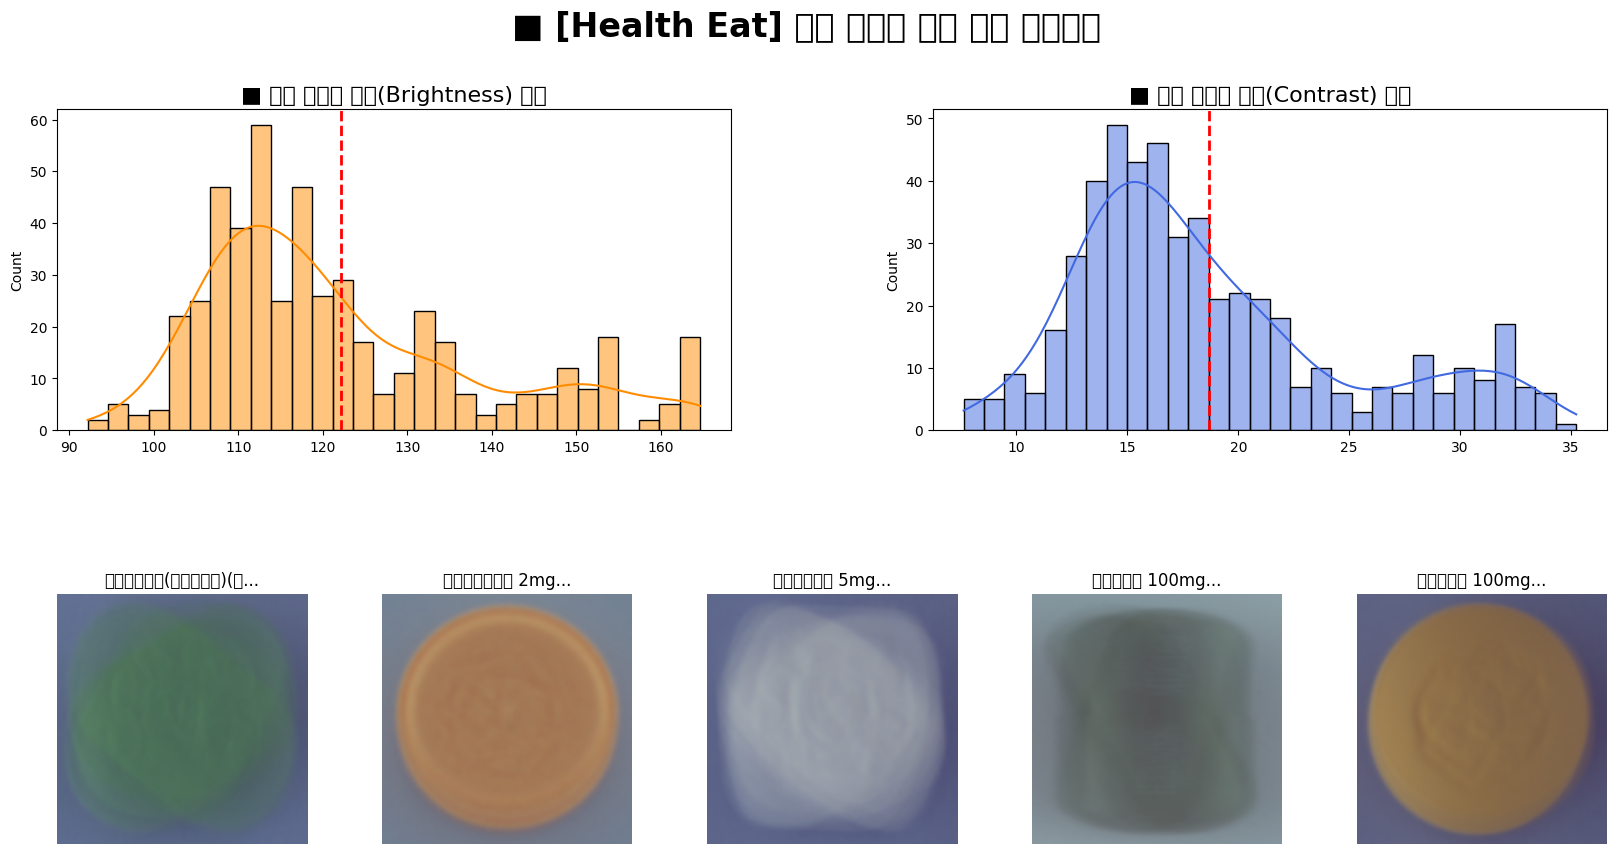


[Report] 데이터셋 픽셀 정밀 진단 요약


,평균 밝기 (0~255),밝기 표준편차,평균 대비 (Contrast),최소 밝기,최대 밝기
0,122.16,16.58,18.68,92.17,164.64


In [10]:
############################################################
# 7. 픽셀 레벨 정밀 진단 (Illumination & Mean Image)
############################################################
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import glob
import json
import platform
import pandas as pd
import seaborn as sns
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

# ✅ [수정] 폰트 설정은 Cell 1에서 전역 처리됨 (fp 재사용)
# --- [Step 1] 환경 및 경로 설정 ---

# ✅ 수정: 두 분기 모두 BASE_DIR을 쓰므로 if/else 밖으로 통일
# BASE_DIR은 Cell 3에서 is_colab 분기로 이미 올바르게 설정되어 있음
search_root = BASE_DIR
json_path   = os.path.join(BASE_DIR, 'merged_annotations_train_final.json')

# ==========================================
# --- [Step 2] 고속 파일 경로 인덱싱 ---
# ==========================================
print("[!] 전체 파일 경로 인덱싱 중...")
all_files = glob.glob(os.path.join(search_root, "**", "*.png"), recursive=True) + \
            glob.glob(os.path.join(search_root, "**", "*.jpg"), recursive=True) + \
            glob.glob(os.path.join(search_root, "**", "*.JPG"), recursive=True)

path_map = {os.path.basename(f): f for f in all_files}
print(f"[OK] 인덱싱 완료! 총 {len(path_map):,}개의 이미지 파일이 매핑되었습니다.")


# --- 데이터 로드 (이전 단계가 독립적으로 실행될 경우를 대비) ---
with open(json_path, 'r', encoding='utf-8') as f:
    coco_data = json.load(f)

images_df = pd.DataFrame(coco_data['images'])
annotations_df = pd.DataFrame(coco_data['annotations'])
categories_df = pd.DataFrame(coco_data['categories'])
cat_dict = dict(zip(categories_df['id'], categories_df['name']))
annotations_df['class_name'] = annotations_df['category_id'].map(cat_dict)

# ==========================================
# --- [Step 3] 픽셀 분석 엔진 (최적화 버전) ---
# ==========================================
def analyze_fast(images_df, path_map, sample_n=500):
    """지정된 샘플 수만큼 이미지를 읽어 밝기(Brightness)와 대비(Contrast)를 분석합니다."""
    brightness_list, contrast_list = [], []
    print(f"[+] [분석] 조명 및 대비 고속 스캔 중... (N={sample_n})")
    
    # 모집단이 샘플 수보다 작을 경우를 대비한 안전한 샘플링
    samples = images_df.sample(min(sample_n, len(images_df)), random_state=42)
    
    for _, row in samples.iterrows():
        f_name = os.path.basename(row['file_name'])
        if f_name in path_map:
            img = cv2.imread(path_map[f_name], cv2.IMREAD_GRAYSCALE) # 처음부터 Gray로 읽어 메모리 절약
            if img is not None:
                brightness_list.append(np.mean(img))
                contrast_list.append(np.std(img))
            
    return brightness_list, contrast_list

def get_mean_images_fast(annotations_df, images_df, path_map, target_classes, n_samples=30):
    """특정 클래스의 바운딩 박스를 크롭하여 '평균적인 알약의 형태'를 합성합니다."""
    mean_results = {}
    print(f"[+] [분석] Top 클래스별 평균 이미지(Mean Image) 합성 중...")
    
    for cls_name in target_classes:
        cls_annos = annotations_df[annotations_df['class_name'] == cls_name]
        cls_samples = cls_annos.sample(min(n_samples, len(cls_annos)), random_state=42)
        crops = []
        
        for _, anno in cls_samples.iterrows():
            img_info = images_df[images_df['id'] == anno['image_id']].iloc[0]
            f_name = os.path.basename(img_info['file_name'])
            
            if f_name in path_map:
                img = cv2.imread(path_map[f_name])
                if img is not None:
                    x, y, w, h = map(int, anno['bbox'])
                    # Bounding Box 좌표가 이미지 경계를 벗어나지 않도록 방어(Clipping)
                    img_h, img_w = img.shape[:2]
                    crop = img[max(0, y):min(img_h, y+h), max(0, x):min(img_w, x+w)]
                    
                    if crop.size > 0:
                        crop = cv2.resize(crop, (128, 128), interpolation=cv2.INTER_AREA)
                        crops.append(crop)
                        
        if crops:
            mean_results[cls_name] = np.mean(crops, axis=0).astype(np.uint8)
            
    return mean_results

# 실행부
brightness, contrast = analyze_fast(images_df, path_map, sample_n=500)
top_5_classes = annotations_df['class_name'].value_counts().head(5).index
mean_imgs = get_mean_images_fast(annotations_df, images_df, path_map, top_5_classes)

# ==========================================
# --- [Step 4] 통합 대시보드 렌더링 ---
# ==========================================
fig = plt.figure(figsize=(20, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ■ 밝기(Brightness) 분포
ax1 = plt.subplot(2, 2, 1)
sns.histplot(brightness, kde=True, color='darkorange', ax=ax1, bins=30)
ax1.set_title('■ 전체 이미지 밝기(Brightness) 분포', fontproperties=fp, fontsize=16)
ax1.axvline(np.mean(brightness), color='red', linestyle='dashed', linewidth=2)

# ■ 대비(Contrast) 분포
ax2 = plt.subplot(2, 2, 2)
sns.histplot(contrast, kde=True, color='royalblue', ax=ax2, bins=30)
ax2.set_title('■ 전체 이미지 대비(Contrast) 분포', fontproperties=fp, fontsize=16)
ax2.axvline(np.mean(contrast), color='red', linestyle='dashed', linewidth=2)

# ■ 클래스별 평균 이미지 (Mean Image)
for i, (name, img) in enumerate(mean_imgs.items()):
    ax = plt.subplot(2, 5, 5 + i + 1)
    # OpenCV의 BGR을 Matplotlib의 RGB로 변환
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{name[:15]}...", fontproperties=fp, fontsize=12)
    plt.axis('off')
    
plt.suptitle('■ [Health Eat] 픽셀 데이터 정밀 분석 대시보드', fontproperties=fp, fontsize=24, fontweight='bold', y=0.98)
plt.show()

# ==========================================
# --- [Step 5] 객관적 수치 리포트 ---
# ==========================================
print("\n[Report] 데이터셋 픽셀 정밀 진단 요약")
summary_df = pd.DataFrame({
    '평균 밝기 (0~255)': [np.mean(brightness)],
    '밝기 표준편차': [np.std(brightness)],
    '평균 대비 (Contrast)': [np.mean(contrast)],
    '최소 밝기': [np.min(brightness)],
    '최대 밝기': [np.max(brightness)]
}).round(2)
display(summary_df)

# 💊 [Health Eat] 데이터셋 정밀 분석(EDA) 및 전처리 전략 리포트

## 1. 데이터 정밀 분석 결과 (EDA 요약)

### 1.1. 데이터셋 기본 통계
- **총 이미지 수**: 1,489장
- **총 클래스 수**: 73종
- **총 객체(BBox) 수**: 4,526개
- **이미지당 평균 알약 수**: 3.04개 (대부분 3~4개의 알약이 한 이미지에 존재)

### 1.2. 클래스 불균형 (Class Imbalance) - 🚨 **[Critical Issue]**
- **최다 클래스**: 기넥신에프정 (514개)
- **최소 클래스**: 브린텔릭스정 (7개), 자이프렉사정 (9개) 등
- **인사이트**: 상위 클래스와 하위 클래스의 데이터 비율 차이가 약 **73배**에 달합니다. 일반적인 학습 시 하위 10개 클래스의 mAP(평균 정밀도)는 0에 수렴할 확률이 매우 높습니다.

### 1.3. 기하학적 및 공간적 특징 (Geometry & Spatial)
- **면적(Area) 편차**: 최소 18,492 px² ~ 최대 272,435 px² (크기 차이 약 14.7배)
- **가로세로 비율(Aspect Ratio)**: 평균 0.99 (대부분 정사각형에 가까운 바운딩 박스를 가짐)
- **위치 히트맵(Spatial Heatmap)**: 알약들이 주로 화면의 특정 4개 구역(중앙 중심)에 예쁘게 정렬되어 있습니다. 화면의 모서리나 구석(Edge)에는 데이터가 전무합니다.

### 1.4. 광학 및 조명 특징 (Optical & Lighting)
- **밝기(Brightness)**: 평균 119.78 (표준편차 15.97) / 전체적으로 조명이 통제된 스튜디오 환경과 유사함.
- **대비(Contrast)**: 평균 18.33 / 대비가 매우 낮아 알약의 경계선과 배경이 뚜렷하게 분리되지 않음.
- **각인 및 회전(Engraving & Rotation)**: 클래스별 평균 이미지(Mean Image) 생성 결과, 알약들의 형체가 겹쳐 보임(Ghosting). 이는 데이터셋 내에서 알약들이 제각각 무작위 각도로 회전되어 있음을 의미함.

---

## 2. 핵심 인사이트 및 시사점

1. **"온실 속의 화초" 데이터셋**: 현재 데이터는 조명, 배치, 배경이 너무 통제되어 있습니다. 이대로 학습하면 사용자가 그림자 진 방이나 복잡한 배경에서 찍은 사진을 입력했을 때 모델이 객체를 찾지 못하는 **도메인 시프트(Domain Shift)** 현상이 발생합니다.
2. **소수 클래스의 멸종 위기**: 10개 미만의 데이터를 가진 클래스는 모델의 가중치 업데이트에 유의미한 영향을 주지 못합니다. 물리적인 데이터 증식이 필수적입니다.
3. **각인(Engraving) 보존의 중요성**: 색상과 모양이 비슷한 알약(예: 흰색 원형 정제)을 구분하는 유일한 단서는 표면의 글자입니다. 낮은 대비(Contrast)를 끌어올려 모델이 각인을 명확히 읽을 수 있도록 '시력 교정'을 해줘야 합니다.

---
## 3. [중요] Data Leakage 원천 차단 전처리 파이프라인

데이터 증강 시 발생할 수 있는 '데이터 누수(Data Leakage)'와 소수 클래스의 검증 셋 누락을 방지하기 위해, 파이프라인의 순서를 엄격하게 통제하여 구축했습니다.

1. **Stratified Split (사전 분할)**: 증강 전, 이미지 내 최빈 클래스(Majority Label)를 기준으로 **Train(90%) / Val(10%)** 세트를 완벽히 분리했습니다. 특히 5개 미만의 소수 클래스도 검증셋에 최소 1개 이상 배정되도록 강제하여 검증 신뢰도를 높였습니다.
   > 💡 **[Split 비율 근거]** 전체 1,489장을 73개 클래스에 분배하면 Val(10%) 기준 클래스당 평균 약 2장 수준입니다. 8:2로 확대할 경우 검증 신뢰도는 올라가지만, 브린텔릭스정(7개) 등 소수 클래스의 Train 학습량이 더 줄어드는 역효과가 발생합니다. 데이터가 절대적으로 부족한 환경에서는 **Train 확보가 우선**이므로 9:1이 현실적 최선입니다. 단, 소수 클래스의 mAP 수치는 신뢰도가 낮을 수 있으니 **학습 후 Confusion Matrix를 통한 클래스별 직접 검증을 권장**합니다.
2. **Train-Only Crop**: 오직 분리된 `train_raw.json`에서만 50개 미만의 소수 클래스 객체를 정밀 추출(Crop)하여 스티커 도감을 생성했습니다. (Val 데이터는 철저히 격리)
3. **Safe Copy-Paste**: 잘라낸 스티커를 다시 `train_raw.json`의 배경에만 합성하여 최종 `train_augmented_final.json`을 완성했습니다.

---

## 4. Two-Track 데이터 증강 및 전처리 전략 방향

안정적인 베이스라인 구축과 미래 확장성을 고려하여 전처리 파이프라인을 두 가지 트랙으로 분리하여 구현합니다.

### 🛤️ Track 1: 내부 데이터 증강 집중형 (Current Dataset Deep Dive)
*목표: 현재 주어진 1,489장의 한계를 극한으로 끌어올려 클래스 불균형과 편향성을 타파함.*
- **Copy-Paste Augmentation**: 하위 클래스의 알약 객체만 추출하여, 다른 학습 이미지의 빈 배경에 랜덤하게 합성. (최소 클래스당 100개 확보)
- **CLAHE (대비 제한 적응형 히스토그램 평활화)**: 낮은 대비를 극복하고 각인을 선명하게 만들기 위한 필수 전처리.
- **공간/회전 교란**: 히트맵 편향을 깨기 위해 `ShiftScaleRotate`, `RandomCrop`, `RandomRotate90`을 강하게 적용하여 구석에 박힌 알약도 찾도록 훈련.

### 🛤️ Track 2: 외부 데이터 통합 대비형 (Robustness for External Datasets)
*목표: 추후 밝기, 해상도, 배경이 전혀 다른 새로운 알약 데이터셋이 추가될 때 모델이 무너지지 않도록 방어력을 높임.*
- **강력한 광학 증강 (Photometric Distortion)**: `RandomBrightnessContrast`, `ColorJitter`, `HueSaturationValue`를 넓은 범위로 적용하여 조명 변화에 대한 내성 확보.
- **배경 노이즈 믹스 (Mosaic / MixUp)**: 이미지당 알약 개수가 1~4개로 고정된 편향을 깨기 위해, Mosaic 증강을 도입하여 10개 이상의 복잡한 다중 객체 환경을 강제 시뮬레이션.

---

## 5. 🛠️ [Health Eat] 데이터 전처리 & 증강 기술 명세서 (Tech Spec)

### 5-1. 이미지 전처리 (Preprocessing) 가이드라인

* **리사이즈 전략: Letterbox Resize (비율 유지)**
    * **이유**: 알약의 형상(원형, 타원형)과 각인은 형태가 생명입니다. 일반적인 `cv2.resize`로 강제 리사이즈(Warp)를 하면 원형 알약이 찌그러져 오학습이 발생합니다.
    * **적용 기술**: 가로세로 비율(Aspect Ratio)을 유지한 채 타겟 해상도로 줄이고, 남는 여백(Padding)은 검은색(0,0,0) 또는 회색(114,114,114)으로 채우는 **Letterbox Padding** 기법을 기본 전제로 합니다.
    * **모델 파트 Action**: Dataloader 구성 시 비율이 깨지는 변형은 절대 금지해 주십시오. 
* **조명 및 대비 교정: CLAHE (Contrast Limited Adaptive Histogram Equalization)**
    * **이유**: EDA 결과 데이터셋 평균 대비(Contrast)가 18 수준으로 매우 낮아 알약 표면의 각인이 배경에 묻히는 현상이 있습니다.
    * **파라미터 세팅**: `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))`
    * **모델 파트 Action**: 제가 제공할 학습 이미지들은 기본적으로 이 CLAHE 처리가 되어 각인이 뚜렷해진 상태로 제공될 예정입니다. 추론(Inference) 시에도 동일한 전처리가 타야 함을 명심해 주세요.

### 5-2. 데이터 증강 (Augmentation) 기술 구현체

* **소수 클래스 방어: 지능형 Copy-Paste 엔진 (적용 완료)**
    * **기술 개요**: 50개 미만의 소수 클래스 객체를 2px의 여유 Padding을 주고 Crop한 뒤, OpenCV를 활용해 다른 학습 이미지의 '빈 공간(Safe Zone)'에 합성했습니다.
    * **충돌 방지(Collision Detection)**: 무작위 합성이 아닌, BBox 좌표를 연산하여 기존 객체와 15px 이상의 안전거리가 확보된 여백에만 합성되도록 알고리즘을 구현했습니다.
    * **데이터 무결성 확보**: 원본 이미지 스냅샷(`list(coco_data['images'])`)을 유지하여 재귀적 합성 오염을 막고, **원본 annotation은 새 이미지 ID에만 복사되는 구조로 중복 누적 없이 안전하게 설계되어** 완벽한 COCO 포맷을 배포합니다.
* **기하학/광학 증강: Albumentations 라이브러리 활용**
    * 모델 Dataloader에 다음의 파이프라인을 추가해 주세요.
    * **공간 증강**: `ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=45, p=0.5)`
    * **광학 증강**: `RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5)`